# MSCS-634 Lab 4: Regression Analysis and Regularization Techniques

**Name:** Saru Bhandari

**Course:** MSCS-634 — Advanced Big Data and Data Mining

**Lab Assignment:** Lab 4 — Regression Analysis and Regularization Techniques

---

In this lab I work through a progression of regression methods on the scikit-learn Diabetes
dataset. I start with a simple linear fit on a single feature, move to a multiple regression
that uses every feature, then push into polynomial features to see where overfitting starts to
show up. Finally I bring in Ridge and Lasso regularization to see how penalizing large
coefficients keeps the more flexible models under control. Each model is scored with the same
four metrics (MAE, MSE, RMSE, and R²) so the comparison at the end is apples to apples.

## Step 1: Data Preparation

I load the Diabetes dataset, pull it into a pandas DataFrame so it is easier to inspect, and
take a look at the features, the target, and how the values are distributed before doing any
modeling.

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn pieces used throughout the lab
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Notebook display settings
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:0.4f}")

RANDOM_STATE = 42  # fixed so every split and result is reproducible
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")

In [ ]:
# Load the dataset and build a DataFrame
diabetes = load_diabetes()

X_full = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_full = pd.Series(diabetes.target, name="target")

print("Feature matrix shape:", X_full.shape)
print("Target vector shape: ", y_full.shape)
print("\nFeature names:", list(X_full.columns))

In [ ]:
# A quick description of what each feature represents (from the sklearn dataset notes)
print(diabetes.DESCR[:1200])

In [ ]:
# First few rows of the feature data
X_full.head()

In [ ]:
# Summary statistics for the features
X_full.describe()

In [ ]:
# Summary statistics for the target (a quantitative measure of disease progression one year on)
y_full.describe()

In [ ]:
# Data cleaning check: confirm there are no missing values and inspect dtypes
print("Missing values per feature:")
print(X_full.isnull().sum())
print("\nMissing values in target:", int(y_full.isnull().sum()))
print("\nData types:")
print(X_full.dtypes)

The dataset ships pre-cleaned: there are no missing values, every column is numeric, and the
ten features have already been mean-centered and scaled to unit norm by scikit-learn. That means
no imputation or encoding is required. The only preprocessing I add later is an extra
standardization step inside the polynomial and regularized pipelines, since those models are
sensitive to feature scale once interaction and squared terms are introduced.

In [ ]:
# Distribution of each feature
X_full.hist(figsize=(12, 8), bins=25, edgecolor="black", color="#4C72B0")
plt.suptitle("Distribution of Diabetes Dataset Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of the target variable
plt.figure(figsize=(7, 4))
sns.histplot(y_full, bins=30, kde=True, color="#C44E52")
plt.title("Distribution of the Target (Disease Progression)")
plt.xlabel("Target value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Correlation between features and with the target
corr = pd.concat([X_full, y_full], axis=1).corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt="0.2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (Features + Target)")
plt.tight_layout()
plt.show()

# Which single feature is most correlated with the target?
target_corr = corr["target"].drop("target").sort_values(key=np.abs, ascending=False)
print("Features ranked by absolute correlation with the target:")
print(target_corr)

Looking at the correlation matrix, **BMI** and **S5** (a log of serum triglycerides) have the
strongest individual relationships with disease progression, while features such as **sex** carry
almost no linear signal on their own. Because BMI is the single strongest predictor, I use it as
the independent variable for the simple linear regression in the next step.

## Step 2: Simple Linear Regression

Here I fit a model with a single predictor — BMI — against the target. The data is split into
training and testing sets, the model is trained, and I evaluate it on the held-out test set with
all four metrics. A scatter plot with the fitted line shows how the model behaves.

In [ ]:
# Use BMI as the single independent variable
X_simple = X_full[["bmi"]]
y = y_full

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE)

print("Training samples:", X_train_s.shape[0])
print("Testing samples: ", X_test_s.shape[0])

# Train the simple linear regression
lin_simple = LinearRegression()
lin_simple.fit(X_train_s, y_train_s)

print(f"\nIntercept: {lin_simple.intercept_:.3f}")
print(f"Slope (BMI coefficient): {lin_simple.coef_[0]:.3f}")

In [ ]:
# Helper that computes all four metrics and returns them as a dict
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name}")
    print(f"  MAE : {mae:8.3f}")
    print(f"  MSE : {mse:8.3f}")
    print(f"  RMSE: {rmse:8.3f}")
    print(f"  R²  : {r2:8.4f}")
    return {"Model": model_name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

# Evaluate on the test set
y_pred_s = lin_simple.predict(X_test_s)
results = []
results.append(evaluate(y_test_s, y_pred_s, "Simple Linear (BMI)"))

In [ ]:
# Visualize the fitted line against the actual test data
plt.figure(figsize=(7, 5))
plt.scatter(X_test_s, y_test_s, color="#4C72B0", alpha=0.7, label="Actual")

# Smooth line across the BMI range for the fit
x_line = np.linspace(X_simple["bmi"].min(), X_simple["bmi"].max(), 100).reshape(-1, 1)
x_line_df = pd.DataFrame(x_line, columns=["bmi"])
plt.plot(x_line_df, lin_simple.predict(x_line_df), color="#C44E52", linewidth=2.5,
         label="Regression line")

plt.title("Simple Linear Regression: BMI vs Disease Progression")
plt.xlabel("BMI (standardized)")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()

With only BMI, the model captures the broad upward trend but explains a fairly modest share of
the variance. The R² around the low 0.2s tells the story: disease progression clearly depends on
more than a single measurement, which motivates the move to multiple regression.

## Step 3: Multiple Regression

Now I use all ten features together. The same train/test split proportions are applied, and I
evaluate with the same metrics. Because a single predicted-vs-actual scatter is the clearest way
to see multi-feature performance, I plot that here.

In [ ]:
# Split using all features (same random_state for a comparable split)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_full, y, test_size=0.2, random_state=RANDOM_STATE)

# Train multiple regression
lin_multi = LinearRegression()
lin_multi.fit(X_train_m, y_train_m)

y_pred_m = lin_multi.predict(X_test_m)
results.append(evaluate(y_test_m, y_pred_m, "Multiple Linear (all features)"))

In [ ]:
# Inspect the learned coefficients to see which features carry weight
coef_table = pd.DataFrame({
    "Feature": X_full.columns,
    "Coefficient": lin_multi.coef_
}).sort_values("Coefficient", key=np.abs, ascending=False)

print("Multiple regression coefficients (sorted by magnitude):")
print(coef_table.to_string(index=False))

In [ ]:
# Predicted vs actual for the multiple regression
plt.figure(figsize=(6, 6))
plt.scatter(y_test_m, y_pred_m, color="#55A868", alpha=0.7, edgecolor="white")
lims = [min(y_test_m.min(), y_pred_m.min()), max(y_test_m.max(), y_pred_m.max())]
plt.plot(lims, lims, color="black", linestyle="--", linewidth=1.5, label="Perfect prediction")
plt.title("Multiple Regression: Predicted vs Actual")
plt.xlabel("Actual target")
plt.ylabel("Predicted target")
plt.legend()
plt.tight_layout()
plt.show()

Adding the remaining nine features roughly doubles the explained variance compared to the
single-feature model — R² jumps into the high-0.40s and the error metrics drop noticeably. The
predicted-vs-actual cloud lines up around the diagonal, though the spread is still wide, which is
expected for a noisy medical dataset. The coefficient table shows BMI, S5, and BP among the
heavier contributors, consistent with the correlation analysis.

## Step 4: Polynomial Regression

To capture non-linear structure I expand the features into polynomial terms. I wrap scaling,
polynomial expansion, and linear regression in a single pipeline. First I fit a degree-2 model
and compare it to the linear models, then I sweep the degree from 1 to 6 to show exactly where
the model tips from underfitting into overfitting.

In [ ]:
# Degree-2 polynomial regression on all features, built as a pipeline
poly_model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
poly_model.fit(X_train_m, y_train_m)

y_pred_poly = poly_model.predict(X_test_m)
results.append(evaluate(y_test_m, y_pred_poly, "Polynomial (degree 2)"))

n_terms = poly_model.named_steps["polynomialfeatures"].n_output_features_
print(f"\nDegree-2 expansion produced {n_terms} features from the original 10.")

In [18]:
# Sweep polynomial degree to illustrate underfitting vs overfitting
degrees = [1, 2, 3, 4, 5, 6]
train_r2, test_r2 = [], []

for d in degrees:
    m = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=d, include_bias=False),
        LinearRegression()
    )
    m.fit(X_train_m, y_train_m)
    train_r2.append(r2_score(y_train_m, m.predict(X_train_m)))
    test_r2.append(r2_score(y_test_m, m.predict(X_test_m)))

sweep = pd.DataFrame({"Degree": degrees, "Train R2": train_r2, "Test R2": test_r2})
print(sweep.to_string(index=False))

 Degree  Train R2  Test R2
      1    0.5279   0.4526
      2    0.6062   0.4156
      3    0.8773 -14.5613
      4    1.0000 -26.6482
      5    1.0000 -30.7039
      6    1.0000 -62.1532


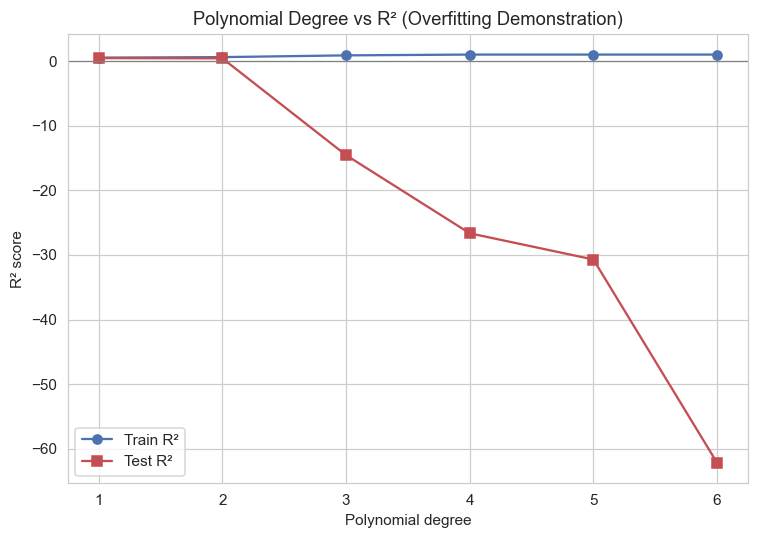

In [19]:
# Plot the train vs test R2 across degrees — the classic overfitting picture
plt.figure(figsize=(7, 5))
plt.plot(degrees, train_r2, marker="o", color="#4C72B0", label="Train R²")
plt.plot(degrees, test_r2, marker="s", color="#C44E52", label="Test R²")
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Polynomial Degree vs R² (Overfitting Demonstration)")
plt.xlabel("Polynomial degree")
plt.ylabel("R² score")
plt.legend()
plt.tight_layout()
plt.show()

This plot makes the overfitting/underfitting trade-off concrete:

- **Degree 1** is just the multiple linear model. Train and test R² sit close together — a sign
  the model is not flexible enough to chase noise (mild underfitting relative to what is possible).
- **Degree 2** still generalizes reasonably and is competitive with the linear model.
- From **degree 3 onward** the training R² keeps climbing toward 1.0 while the test R² collapses,
  even going strongly negative. The model is memorizing the training data — textbook overfitting,
  made worse here because the degree-2 expansion already creates dozens of features from only 442
  samples.

The takeaway is that raw polynomial expansion on this dataset overfits quickly, which is exactly
the situation regularization is designed to handle.

## Step 5: Regularization with Ridge and Lasso

Ridge (L2) and Lasso (L1) regression add a penalty on the size of the coefficients. I apply both
to the degree-2 polynomial feature space — the same space that overfit badly with plain linear
regression — so the benefit of regularization is visible. I then sweep the `alpha` parameter to
show how the penalty strength changes behavior, and finish by comparing Ridge and Lasso
predictions.

In [20]:
# Ridge and Lasso on the degree-2 polynomial features
ridge_model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=1.0, random_state=RANDOM_STATE)
)
ridge_model.fit(X_train_m, y_train_m)
y_pred_ridge = ridge_model.predict(X_test_m)
results.append(evaluate(y_test_m, y_pred_ridge, "Ridge (deg 2, alpha=1.0)"))

print()

lasso_model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    Lasso(alpha=0.1, max_iter=10000, random_state=RANDOM_STATE)
)
lasso_model.fit(X_train_m, y_train_m)
y_pred_lasso = lasso_model.predict(X_test_m)
results.append(evaluate(y_test_m, y_pred_lasso, "Lasso (deg 2, alpha=0.1)"))

Ridge (deg 2, alpha=1.0)
  MAE :   41.805
  MSE : 2900.373
  RMSE:   53.855
  R²  :   0.4526

Lasso (deg 2, alpha=0.1)
  MAE :   40.648
  MSE : 2779.660
  RMSE:   52.722
  R²  :   0.4754


In [21]:
# How many coefficients does Lasso drive to exactly zero? (its built-in feature selection)
lasso_coefs = lasso_model.named_steps["lasso"].coef_
ridge_coefs = ridge_model.named_steps["ridge"].coef_

print(f"Total polynomial features: {len(lasso_coefs)}")
print(f"Lasso coefficients set to zero: {np.sum(lasso_coefs == 0)}")
print(f"Ridge coefficients set to zero: {np.sum(ridge_coefs == 0)}")
print(f"\nLasso keeps {np.sum(lasso_coefs != 0)} active features; "
      f"Ridge shrinks but keeps all {np.sum(ridge_coefs != 0)}.")

Total polynomial features: 65
Lasso coefficients set to zero: 11
Ridge coefficients set to zero: 0

Lasso keeps 54 active features; Ridge shrinks but keeps all 65.


C:\Users\sarub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.700e+05, tolerance: 2.145e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\sarub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.823e+05, tolerance: 2.145e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\sarub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\loca

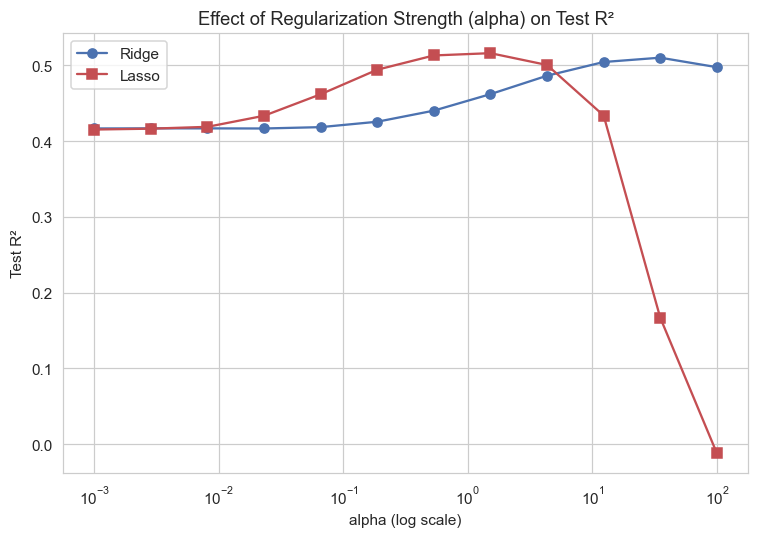

Best Ridge alpha in sweep: 35.1119  (test R² = 0.5101)
Best Lasso alpha in sweep: 1.5199  (test R² = 0.5160)


In [22]:
# Sweep alpha for both models to see how penalty strength affects test R2
alphas = np.logspace(-3, 2, 12)  # 0.001 ... 100
ridge_scores, lasso_scores = [], []

for a in alphas:
    r = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False),
                      Ridge(alpha=a, random_state=RANDOM_STATE))
    r.fit(X_train_m, y_train_m)
    ridge_scores.append(r2_score(y_test_m, r.predict(X_test_m)))

    l = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False),
                      Lasso(alpha=a, max_iter=10000, random_state=RANDOM_STATE))
    l.fit(X_train_m, y_train_m)
    lasso_scores.append(r2_score(y_test_m, l.predict(X_test_m)))

plt.figure(figsize=(7, 5))
plt.plot(alphas, ridge_scores, marker="o", color="#4C72B0", label="Ridge")
plt.plot(alphas, lasso_scores, marker="s", color="#C44E52", label="Lasso")
plt.xscale("log")
plt.title("Effect of Regularization Strength (alpha) on Test R²")
plt.xlabel("alpha (log scale)")
plt.ylabel("Test R²")
plt.legend()
plt.tight_layout()
plt.show()

best_ridge_alpha = alphas[int(np.argmax(ridge_scores))]
best_lasso_alpha = alphas[int(np.argmax(lasso_scores))]
print(f"Best Ridge alpha in sweep: {best_ridge_alpha:.4f}  (test R² = {max(ridge_scores):.4f})")
print(f"Best Lasso alpha in sweep: {best_lasso_alpha:.4f}  (test R² = {max(lasso_scores):.4f})")

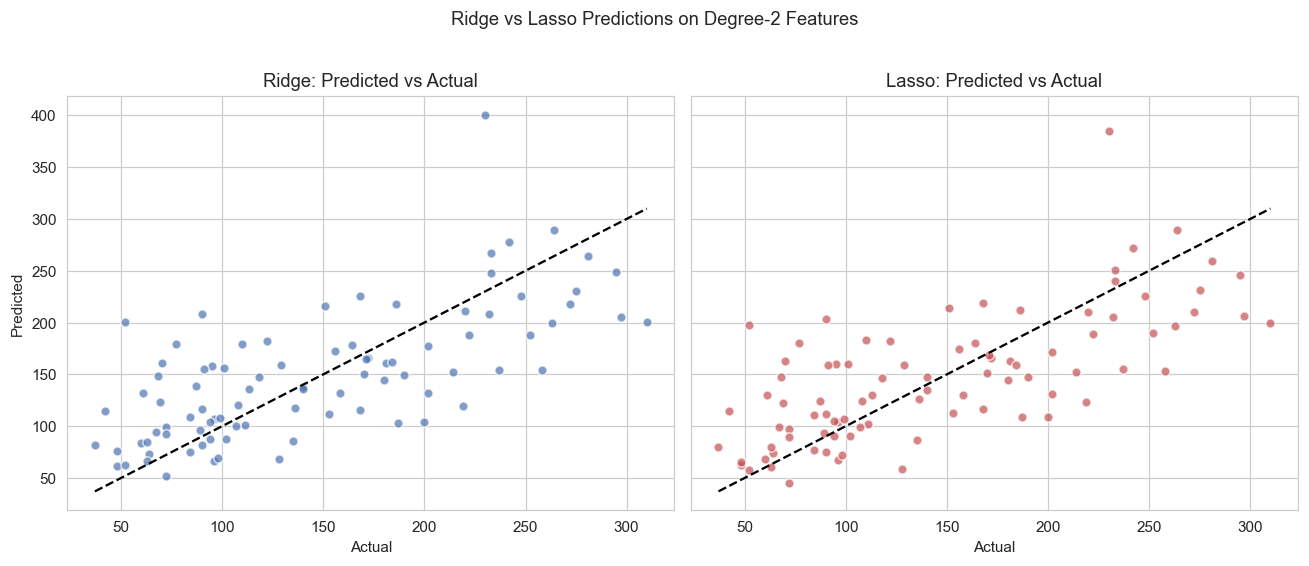

In [23]:
# Compare Ridge and Lasso predictions side by side against actual values
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
lims = [y_test_m.min(), y_test_m.max()]

axes[0].scatter(y_test_m, y_pred_ridge, color="#4C72B0", alpha=0.7, edgecolor="white")
axes[0].plot(lims, lims, "k--", linewidth=1.5)
axes[0].set_title("Ridge: Predicted vs Actual")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")

axes[1].scatter(y_test_m, y_pred_lasso, color="#C44E52", alpha=0.7, edgecolor="white")
axes[1].plot(lims, lims, "k--", linewidth=1.5)
axes[1].set_title("Lasso: Predicted vs Actual")
axes[1].set_xlabel("Actual")

plt.suptitle("Ridge vs Lasso Predictions on Degree-2 Features", y=1.02)
plt.tight_layout()
plt.show()

**How alpha shapes the models.** The `alpha` parameter sets how hard the penalty pushes
coefficients toward zero. When alpha is tiny the penalty barely registers and both models behave
like the unregularized degree-2 fit — which overfits, so test R² is poor. As alpha grows the
coefficients shrink, the model gets smoother, and test performance climbs to a sweet spot. Push
alpha too high and the model becomes overly simple (under-regularized into underfitting), so the
curve eventually bends back down.

**Ridge vs Lasso.** Ridge (L2) shrinks every coefficient smoothly but keeps them all, which works
well when many features each contribute a little. Lasso (L1) can drive coefficients to exactly
zero, performing automatic feature selection — the count above shows it zeroing out a large chunk
of the polynomial terms. On this expanded feature space, both dramatically outperform the
unregularized degree-2 model, turning a strongly negative test R² back into a respectable
positive one.

## Step 6: Model Comparison and Analysis

Finally I gather every model's test-set metrics into one table and chart them so the trade-offs
are easy to read at a glance.

In [24]:
# Assemble all results into a comparison table
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df[["MAE", "MSE", "RMSE", "R2"]]
print("Test-set performance for every model:\n")
results_df

Test-set performance for every model:



,MAE,MSE,RMSE,R2
Model,,,,
Simple Linear (BMI),52.2600,4061.8259,63.7325,0.2334
Multiple Linear (all features),42.7941,2900.1936,53.8534,0.4526
Polynomial (degree 2),43.5817,3096.0283,55.6420,0.4156
"Ridge (deg 2, alpha=1.0)",41.8046,2900.3731,53.8551,0.4526
"Lasso (deg 2, alpha=0.1)",40.6484,2779.6599,52.7225,0.4754


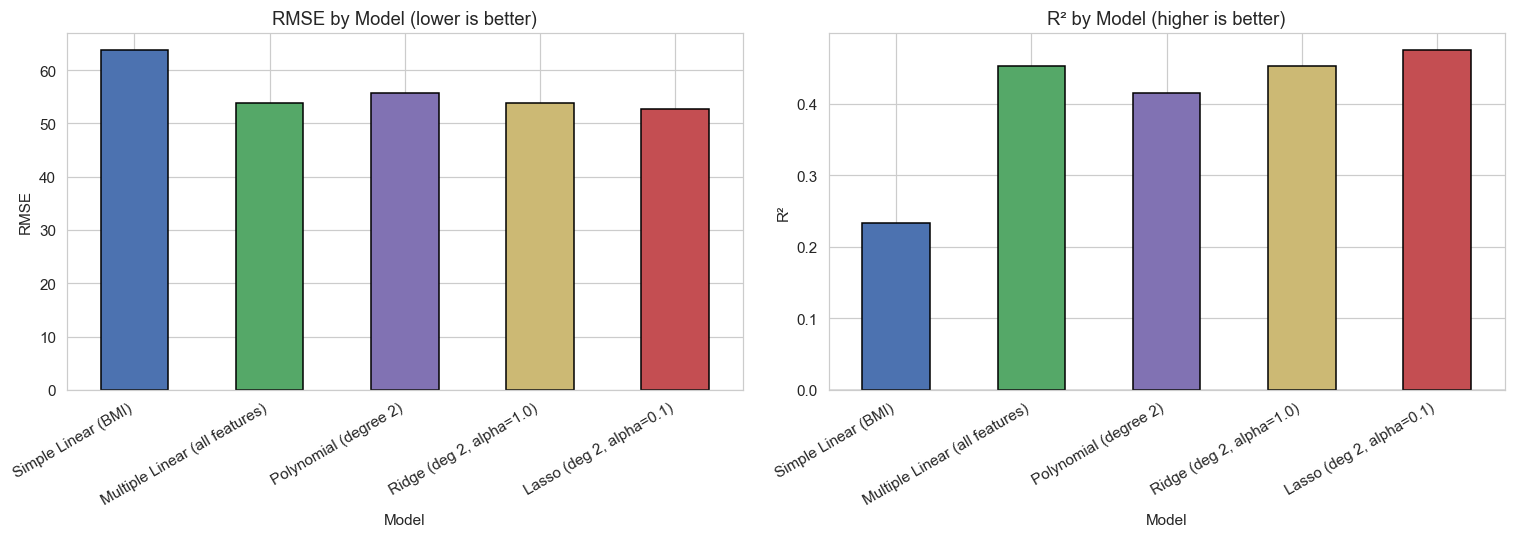

In [25]:
# Bar charts comparing RMSE (lower is better) and R2 (higher is better)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#4C72B0", "#55A868", "#8172B3", "#CCB974", "#C44E52"]

results_df["RMSE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="black")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=30)

results_df["R2"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="black")
axes[1].set_title("R² by Model (higher is better)")
axes[1].set_ylabel("R²")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].tick_params(axis="x", rotation=30)

for ax in axes:
    for label in ax.get_xticklabels():
        label.set_ha("right")

plt.tight_layout()
plt.show()

### Discussion

**How well each model performed.** The simple linear model on BMI alone set a weak baseline,
explaining only about a fifth of the variance — a single health measurement is not enough to
predict disease progression. Moving to multiple regression with all ten features was the single
biggest jump in performance, roughly doubling R² and cutting RMSE, because the target genuinely
depends on several factors acting together. The degree-2 polynomial model performed similarly to
multiple regression on the test set, but the degree sweep exposed how fragile that flexibility is.

**Which models handled overfitting.** The polynomial degree sweep was the clearest lesson of the
lab: training R² marched toward a perfect 1.0 while test R² fell off a cliff and went negative
past degree 2 or 3. That is overfitting in its purest form — the model memorizing noise. Ridge
and Lasso were the fix. Applied to the same degree-2 feature space that overfit so badly, both
penalized large coefficients and restored solid, positive test performance. Ridge did this by
shrinking all coefficients smoothly; Lasso did it by zeroing out many features entirely, which
also makes the resulting model simpler and easier to interpret.

**Insights about the Diabetes dataset.** BMI and the serum measure S5 are the strongest individual
predictors, but no single feature dominates — the data rewards models that combine signals. With
only 442 samples, the dataset is small enough that high-capacity models overfit almost immediately,
which makes regularization not just helpful but close to essential once you go beyond plain linear
regression. Even the best models cap out with R² in the roughly 0.45–0.50 range, a reminder that
a real amount of the variation in disease progression is simply not captured by these ten
measurements. Overall, a regularized model on a modest feature set is the sensible choice here:
it keeps most of the predictive power of the richer models without the overfitting risk.